,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


[9.31132806]
-35.99434897818352
[22.97429165 21.88486626 23.34674477 13.81194483 22.03384751]
[22.6 50.  23.   8.3 21.2]


Text(0.5, 0, 'x')

Text(0, 0.5, 'y')

Text(0.5, 1.0, '回归方程：y=-35.99 + 9.31 * x')

<Figure size 1200x500 with 0 Axes>

Text(0.5, 0, '测试集样本序号')

Text(0, 0.5, '样本的真实值（预测值）')

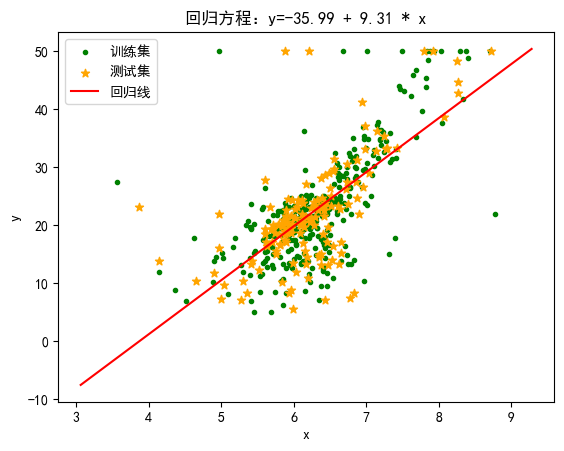

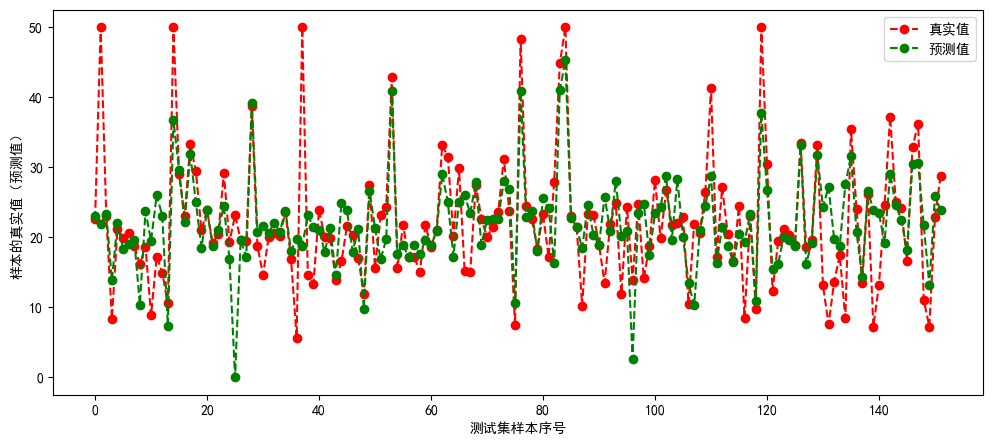

In [1]:
import numpy as np
import pandas as pd

data = pd.read_csv("../data/house.csv", header=0)
data.head()

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X, y = data["RM"].values.reshape(-1, 1), data["MEDV"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
lr = LinearRegression()
lr.fit(X_train, y_train)
print(lr.coef_)
print(lr.intercept_)
y_hat = lr.predict(X_test)
print(y_hat[:5])
print(y_test[:5])

import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "SimHei"
plt.rcParams["axes.unicode_minus"] = False

plt.scatter(X_train, y_train, c="g", marker=".", label="训练集")
plt.scatter(X_test, y_test, c="orange", marker="*", label="测试集")
t = np.linspace(X_train.min() - 0.5, X_train.max() + 0.5, 100)
t2 = lr.intercept_ + lr.coef_[0] * t
plt.plot(t, t2, c="r", label="回归线")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"回归方程：y={lr.intercept_:.2f} + {lr.coef_[0]:.2f} * x")

plt.figure(figsize=(12, 5))
index = np.arange(y_test.shape[0])
plt.plot(index, y_test, label="真实值", color="r", marker="o", ls="--")
plt.plot(index, y_hat, label="预测值", color="g", marker="o", ls="--")
plt.xlabel("测试集样本序号")
plt.ylabel("样本的真实值（预测值）")
plt.legend()

In [ ]:
x1 = np.array([1, 2, 3])
x2 = np.array([4, 5])
# 将1维数组x1与x2扩展为2维数组，并返回。
# 扩展规则：
# 对x1沿着行进行扩展，扩展的行数与x2的元素个数相同。
# 对x2沿着列进行扩展，扩展的列数与x1的元素个数相同。
# 这样扩展之后，我们对位去获取X1与X2的元素，就能够得到原始1维数组x1与x2的笛卡尔积组合。
X1, X2 = np.meshgrid(x1, x2)
print(X1)
print(X2)

[[1 2 3]
 [1 2 3]]
[[4 4 4]
 [5 5 5]]


In [2]:
from mpl_toolkits.mplot3d import Axes3D
%matplotlib qt

X=pd.read_csv('../data/Advertising.csv')
X_partial = X[["TV", "Radio"]].values
y=X['Sales']
lr2 = LinearRegression()
lr2.fit(X_partial, y)
max1, max2 = np.max(X_partial, axis=0)
min1, min2 = np.min(X_partial, axis=0)
x1 = np.linspace(min1, max1, 30)
x2 = np.linspace(min2, max2, 30)
X1, X2 = np.meshgrid(x1, x2)
fig = plt.figure()
ax = Axes3D(fig)
fig.add_axes(ax)
ax.scatter(X_partial[:, 0], X_partial[:, 1], y, color="b")
ax.set_xlabel("TV")
ax.set_ylabel("Radio")
ax.set_zlabel("Sales")
# 绘制拟合平面。
temp = np.array([X1.ravel(), X2.ravel()]).T
y_hat = lr2.predict(temp).reshape(X1.shape)
ax.plot_surface(X1, X2, y_hat, alpha=0.7, rstride=5, cstride=5, cmap=plt.cm.rainbow)

ImportError: Failed to import any of the following Qt binding modules: PyQt6, PySide6, PyQt5, PySide2

In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("MSE：", mean_squared_error(y_test, y_hat))
print("RMSE：", np.sqrt(mean_squared_error(y_test, y_hat)))
print("MAE：", mean_absolute_error(y_test, y_hat))
print("R^2：", r2_score(y_test, y_hat))

# 对于回归模型，也具有score方法，可以返回R^2值，与r2_score计算的结果相同。
# 但是参数不同，对于r2_score，参数为y的预测值与真实值。
# 对于score方法，参数为X与y。
print(lr.score(X_test, y_test))
print(lr.score(X_train, y_train))

MSE： 47.03304747975518
RMSE： 6.858064412044785
MAE： 4.470784290506162
R^2： 0.43514364832115193
0.43514364832115193
0.5026497630040827


In [5]:
import joblib
from sklearn.datasets import load_diabetes

data = load_diabetes()
# print(data)
# print(data.data.shape, data.target.shape)
# print(data.DESCR)
# print(data.feature_names)
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
lr = LinearRegression()
lr.fit(X_train, y_train)
print(lr.coef_)
print(lr.intercept_)
print(lr.predict(X_test[:5]))
# 模型保存。
joblib.dump(lr, "../data/lr.model")

LinearRegression()

[ -52.46478548 -193.50733393  579.49108514  272.453666   -504.64830389
  241.62372969  -69.76596029   86.61313961  721.92083806   26.78067442]
153.71901624380382
[239.67646226 250.52785246 164.85108003 120.27660503 181.73443919]


['../data/lr.model']

In [6]:
# 从之前保存的模型文件中，恢复模型。
model = joblib.load("../data/lr.model")
print(model)
print(model.coef_)
print(model.intercept_)
print(model.predict(X_test[:5]))

LinearRegression()
[ -52.46478548 -193.50733393  579.49108514  272.453666   -504.64830389
  241.62372969  -69.76596029   86.61313961  721.92083806   26.78067442]
153.71901624380382
[239.67646226 250.52785246 164.85108003 120.27660503 181.73443919]
